In [ ]:
%pip install numpy
%pip install pandas
%pip install networkx
%pip install matplotlib
%pip install datashader
%pip install vl-convert-python
%pip install svgutils
%pip install lxml

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from datashader.bundling import hammer_bundle
import vl_convert as vlc
import svgutils.transform as st
from lxml import etree
import xml.etree.ElementTree as ET
from collections import Counter
import json
import io
import re

pd.options.display.max_columns = None

# Nodes and Egdes Refinement

In [13]:
import pandas as pd
import networkx as nx
import json
import vl_convert as vlc
import re
import os

# -- config / paths ---------------------------------------------------------
nodes_url = "data/v2.3/asct-nodes.csv"
edges_url = "data/v2.3/asct-edges.csv"
output_path = "viz_v8.0"
vega_config_dir = f"{output_path}/vega_config"
os.makedirs(vega_config_dir, exist_ok=True)

nodes = pd.read_csv(nodes_url)
edges = pd.read_csv(edges_url)

# -- organ groups you requested (as provided) -------------------------------
organ_groups = [
    ['kidney', 'urinary bladder', 'ureter', 'heart', 'body'],
    ['large intestine', 'liver', 'heart', 'body'],
    ['small intestine', 'liver', 'heart', 'body'],
    ['mouth', 'heart', 'body'],
    ['Pancreas', 'liver', 'heart', 'body'],
    ['prostate gland', 'heart', 'body'],
    ['spleen', 'liver', 'heart', 'body'],
    ['thymus', 'heart', 'body'],
    ['skin of body', 'heart', 'body']
]

# Keep FTUs from your original script (unchanged)
FTUs = [
    'UBERON:0001285', 'UBERON:0001229', 'UBERON:0004205', 'UBERON:0001289',
    'UBERON:0004193', 'UBERON:0004204', 'UBERON:0001291', 'UBERON:0004203',
    'UBERON:0001983', 'UBERON:0001984', 'UBERON:0004647',
    'UBERON:0002299', 'UBERON:8410043',
    'UBERON:0000006', 'UBERON:0001263', 'UBERON:0014726',
    'UBERON:0004179', 'UBERON:0000412', 'UBERON:0013487', 'UBERON:0002073',
    'UBERON:0001213', 'UBERON:0001250', 'UBERON:0001959',
    'UBERON:0002125', 'UBERON:0001831', 'UBERON:0001832',
    'UBERON:0001736', 'UBERON:0001828'
]

# --- helper: slug for filenames -------------------------------------------
def make_slug(organs):
    s = "_".join([str(o).lower().strip() for o in organs])
    s = re.sub(r'[^a-z0-9_]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s or "group"


# Construct Network Vega Viz

In [14]:
# Function to construct network and create vega viz
from logging import config


def construct_network_create_vega_viz(nodes_dataframe, edges_dataframe, 
                                     filename='lung_heart', 
                                     scenegraph=False, 
                                     show_labels=False):
    
    # Make a copy to avoid modifying original
    nodes_df = nodes_dataframe.copy()
    edges_df = edges_dataframe.copy()
    
    # Sort by graph_int_id
    nodes_df = nodes_df.sort_values('graph_int_id').reset_index(drop=True)
    edges_df = edges_df.sort_values('target_int').reset_index(drop=True)
    
    # Create DIRECTED graph for tree structure
    graph = nx.DiGraph()
    for _, edge in edges_df.iterrows():
        graph.add_edge(edge['source_int'], edge['target_int'])
    
    print(f"\nGraph for vega has {graph.number_of_nodes()} nodes")
    print(f"Node 0 in graph: {0 in graph}")
    
    # Get parents - only if node 0 exists
    if 0 in graph:
        parents_dict = dict(nx.bfs_predecessors(graph, source=0))
        nodes_df['parent'] = nodes_df['graph_int_id'].map(parents_dict)
        nodes_df['parent'] = nodes_df['parent'].fillna(0).astype(int)
        print(f"Parents assigned successfully")
    else:
        print("ERROR: Node 0 not in graph for BFS!")
        # Find nodes with in-degree 0
        root_candidates = [n for n in graph.nodes() if graph.in_degree(n) == 0]
        print(f"Root candidates (in-degree=0): {root_candidates}")
        return None
    
    # Set colors
    def get_color(row):
        ontology_id = row.get('ontology_id', '')
        node_type = row.get('type', '')
        if ontology_id in FTUs:
            return '#56a04e'
        elif node_type == 'AS':
            return '#984ea3'
        else:
            return '#ff7f00'
    
    nodes_df['color'] = nodes_df.apply(get_color, axis=1)
    
    # Store original id before renaming
    nodes_df['id_from_ontology_id'] = nodes_df['id']
    
    # Create a new column for the vega id
    nodes_df['vega_id'] = nodes_df['graph_int_id']
    
    if scenegraph:
        # For scenegraph, store name as name_label and use id as name
        nodes_df['name_label'] = nodes_df['name']
        nodes_df['vega_name'] = nodes_df['graph_int_id'].astype(str)
    else:
        # For regular viz, use the actual name
        nodes_df['vega_name'] = nodes_df['name'].fillna('')
    
    # Create JSON - use the vega_ prefixed columns
    # Get the direct children of body (organs connected to body)
    body_children = set(nodes_df[nodes_df['parent'] == 0]['vega_id'].values)

    # Create JSON - use the vega_ prefixed columns
    nodes_list = []
    for idx, row in nodes_df.iterrows():
        node_id = int(row['vega_id'])
        
        # Skip body node (id=0) and its immediate children, but keep everything else
        if node_id == 0 or node_id in body_children:
            continue
        
        node_dict = {
            'id': node_id,
            'name': str(row['vega_name']),
            'type': str(row.get('type', '')),
            'ontology_id': str(row.get('ontology_id', '')),
            'id_from_ontology_id': str(row['id_from_ontology_id']),
            'color': str(row['color']),
            'organ': str(row.get('organ', ''))
        }
        
        # Set parent - for grandchildren of body, set parent to 0 (will appear as roots)
        parent_id = int(row['parent'])
        if parent_id in body_children:
            node_dict['parent'] = 0  # Make them appear as root nodes
        else:
            node_dict['parent'] = parent_id
        
        nodes_list.append(node_dict)

    # Add body node back as a dummy root (optional, for tree structure)
    nodes_list.insert(0, {
        'id': 0,
        'name': '',
        'type': 'AS',
        'ontology_id': 'UBERON:0013702',
        'id_from_ontology_id': 'UBERON:0013702',
        'color': '#984ea3',
        'organ': 'body'
    })
    
    print(f"Total nodes in JSON: {len(nodes_list)}")
    print(f"First node: {nodes_list[0] if nodes_list else 'None'}")
    
    # Load vega config
    with open(f'{output_path}/vega_config/vega_config.json', encoding='utf8') as json_file:
        config = json.load(json_file)
    config['background'] = 'white'
    # config['width'] = 1760
    # config['height'] = 1000
    # tighten viz (not the outer canvas)
    config['autosize'] = {"type": "fit", "contains": "padding"}                 # fit content tightly
    config['padding'] = {"top": 2, "left": 2, "right": 2, "bottom": 2}         # inner whitespace

    # reduce band scale padding (if any band scales exist)
    for s in config.get('scales', []):
        if s.get('type') == 'band':
            s['padding'] = 0

    # reduce node symbol size and move labels closer
    for m in config.get('marks', []):
        if m.get('type') == 'symbol':                                          # node glyphs
            m.setdefault('encode', {}).setdefault('update', {})['size'] = {'value': 40}   # smaller nodes
            m['encode']['update']['strokeWidth'] = {'value': 0.5}
        if m.get('type') == 'text':                                            # labels
            m.setdefault('encode', {}).setdefault('update', {})['fontSize'] = {'value': 6}
            m['encode']['update']['dx'] = {'value': 2}                         # nudge label closer

    # Set data
    config['data'][0]['values'] = nodes_list
    
    # Show labels if requested
    if show_labels:
        if 'marks' in config and len(config['marks']) > 2:
            if 'encode' in config['marks'][-1] and 'update' in config['marks'][-1]['encode']:
                if 'opacity' in config['marks'][-1]['encode']['update']:
                    old_signal = config['marks'][-1]['encode']['update']['opacity']['signal']
                    if old_signal.endswith('0'):
                        config['marks'][-1]['encode']['update']['opacity']['signal'] = old_signal[:-1] + '1'
    
    # Save config
    output_filename = f"{output_path}/{filename}_vega_viz_config.json"
    with open(output_filename, "w") as outfile:
        outfile.write(json.dumps(config, indent=4))
        print(f'File saved as "{output_filename}"')
    
    return config

## Create Vega Viz

In [17]:
def create_vega_viz(config, filename, scenegraph=False):
    '''
    Create the visualization based on the vega config file. The visualization can be saved as SVG or as a scenegraph JSON file.

    Parameters:
    config: dict
        The vega config file.
    filename: str
        The name of the file to be saved.
    scenegraph: bool
        If True, the scenegraph JSON file will be saved, otherwise the SVG file will be saved.
    '''

    if scenegraph:
        scenegraph_data = vlc.vega_to_scenegraph(vg_spec=config)

        with open(f"{output_path}/vega_{filename}_scenegraph.json", "w") as outfile:
            outfile.write(json.dumps(scenegraph_data, indent=4))
        
        print(f"Scenegraph saved as {output_path}/vega_{filename}_scenegraph.json")
        return scenegraph_data
    
    else:
        svg_str = vlc.vega_to_svg(vg_spec=config)

        with open(f"{output_path}/vega_{filename}_viz.svg", "wt") as f:
            f.write(svg_str)
        
        print(f"SVG saved as {output_path}/vega_{filename}_viz.svg")
        return svg_str

In [16]:
all_created_files = []

for group in organ_groups:
    # case-insensitive matching for organs
    group_lower = [g.lower() for g in group]
    organs_to_keep = group_lower  # includes 'body' and 'heart' if present
    
    # Filter nodes (case-insensitive on 'organ' column)
    nodes_copy = nodes.copy()
    nodes_copy['organ_lc'] = nodes_copy['organ'].fillna('').astype(str).str.lower()
    
    filtered_nodes = nodes_copy[
        nodes_copy['organ_lc'].isin(organs_to_keep) |
        (nodes_copy['ontology_id'] == 'UBERON:0013702') |
        (nodes_copy['name'].fillna('').str.lower().str.contains('|'.join([re.escape(x) for x in organs_to_keep]), na=False))
    ].copy()
    
    # Filter edges that connect filtered nodes
    filtered_node_ids = set(filtered_nodes['id'].values)
    filtered_edges = edges[
        (edges['source'].isin(filtered_node_ids)) &
        (edges['target'].isin(filtered_node_ids))
    ].copy()
    
    # Build directed graph and map integer IDs (same logic as your original code)
    initial_graph = nx.DiGraph()
    for _, edge in filtered_edges.iterrows():
        initial_graph.add_edge(edge['source'], edge['target'])
    
    # map ontology id -> integer graph id
    id_to_graph_int_id = {'UBERON:0013702': 0}
    next_id = 1
    
    if 'UBERON:0013702' in initial_graph:
        organs_connected_to_body = list(initial_graph.successors('UBERON:0013702'))
        for organ_id in organs_connected_to_body:
            try:
                # get descendants (organ subtree) and assign ids in DFS order
                descendants = nx.descendants(initial_graph, organ_id)
                descendants.add(organ_id)
                # ensure a source exists for DFS; use organ_id as source
                branch_nodes = list(nx.dfs_preorder_nodes(initial_graph.subgraph(descendants), source=organ_id))
                branch_graph_new_ids = dict(zip(branch_nodes, range(next_id, next_id + len(branch_nodes))))
                id_to_graph_int_id.update(branch_graph_new_ids)
                next_id += len(branch_nodes)
            except Exception:
                # fallback: assign single id if DFS fails
                if organ_id not in id_to_graph_int_id:
                    id_to_graph_int_id[organ_id] = next_id
                    next_id += 1
    else:
        # If no 'body' node, try to assign ids for all connected components
        for comp in nx.weakly_connected_components(initial_graph):
            comp = list(comp)
            for n in comp:
                if n not in id_to_graph_int_id:
                    id_to_graph_int_id[n] = next_id
                    next_id += 1

    # Map integer ids into dataframes
    filtered_nodes['graph_int_id'] = filtered_nodes['id'].map(id_to_graph_int_id)
    filtered_edges['source_int'] = filtered_edges['source'].map(id_to_graph_int_id)
    filtered_edges['target_int'] = filtered_edges['target'].map(id_to_graph_int_id)

    # drop anything without mapped ids (these cannot be placed in vega)
    filtered_nodes = filtered_nodes.dropna(subset=['graph_int_id']).copy()
    filtered_nodes['graph_int_id'] = filtered_nodes['graph_int_id'].astype(int)
    filtered_edges = filtered_edges.dropna(subset=['source_int', 'target_int']).copy()
    filtered_edges['source_int'] = filtered_edges['source_int'].astype(int)
    filtered_edges['target_int'] = filtered_edges['target_int'].astype(int)
    
    # Add keep column (your code expects this)
    filtered_nodes['keep'] = True

    # produce slug and filenames
    slug = make_slug(group)
    
    # create three configs (names, ids/scenegraph, clean)
    cfg_names = construct_network_create_vega_viz(
        filtered_nodes[filtered_nodes['keep']],
        filtered_edges,
        filename=f"{slug}_names",
        scenegraph=False,
        show_labels=True
    )
    cfg_ids = construct_network_create_vega_viz(
        filtered_nodes[filtered_nodes['keep']],
        filtered_edges,
        filename=f"{slug}_ids",
        scenegraph=True,
        show_labels=True
    )
    cfg_clean = construct_network_create_vega_viz(
        filtered_nodes[filtered_nodes['keep']],
        filtered_edges,
        filename=f"{slug}_clean",
        scenegraph=False,
        show_labels=False
    )

    # If configs were created, generate outputs and collect filenames
    created_files_for_group = []
    if cfg_names:
        svg_names = create_vega_viz(cfg_names, f"{slug}_names", scenegraph=False)
        created_files_for_group.append(f"{output_path}/{slug}_names_vega_viz_config.json")
        created_files_for_group.append(f"{output_path}/vega_{slug}_names_viz.svg")
    if cfg_ids:
        scenegraph = create_vega_viz(cfg_ids, f"{slug}_ids", scenegraph=True)
        created_files_for_group.append(f"{output_path}/{slug}_ids_vega_viz_config.json")
        created_files_for_group.append(f"{output_path}/vega_{slug}_ids_scenegraph.json")
    if cfg_clean:
        svg_clean = create_vega_viz(cfg_clean, f"{slug}_clean", scenegraph=False)
        created_files_for_group.append(f"{output_path}/{slug}_clean_vega_viz_config.json")
        created_files_for_group.append(f"{output_path}/vega_{slug}_clean_viz.svg")
    
    all_created_files.append((slug, created_files_for_group))

# -- final: print only filenames (one group per line) -----------------------
for slug, flist in all_created_files:
    if flist:
        print(f"{slug}:")
        for f in flist:
            print(f"  {f}")
    else:
        print(f"{slug}: no files created")


Graph for vega has 381 nodes
Node 0 in graph: True
Parents assigned successfully
Total nodes in JSON: 376
First node: {'id': 0, 'name': '', 'type': 'AS', 'ontology_id': 'UBERON:0013702', 'id_from_ontology_id': 'UBERON:0013702', 'color': '#984ea3', 'organ': 'body'}
File saved as "viz_v8.0/kidney_urinary_bladder_ureter_heart_body_names_vega_viz_config.json"

Graph for vega has 381 nodes
Node 0 in graph: True
Parents assigned successfully
Total nodes in JSON: 376
First node: {'id': 0, 'name': '', 'type': 'AS', 'ontology_id': 'UBERON:0013702', 'id_from_ontology_id': 'UBERON:0013702', 'color': '#984ea3', 'organ': 'body'}
File saved as "viz_v8.0/kidney_urinary_bladder_ureter_heart_body_ids_vega_viz_config.json"

Graph for vega has 381 nodes
Node 0 in graph: True
Parents assigned successfully
Total nodes in JSON: 376
First node: {'id': 0, 'name': '', 'type': 'AS', 'ontology_id': 'UBERON:0013702', 'id_from_ontology_id': 'UBERON:0013702', 'color': '#984ea3', 'organ': 'body'}
File saved as "viz

# Get Coordinates

In [60]:
# Fixed coordinate extraction function
def get_node_coordinates(scenegraph):
    '''Extract node coordinates from scenegraph with INTEGER keys for proper mapping'''
    try:
        # Extract coordinates from scenegraph
        coords_str = {item['text']: (item['x'], item['y']) 
                     for item in scenegraph['scenegraph']['items'][0]['items'][2]['items']}
        
        print(f"\nExtracted {len(coords_str)} coordinates from scenegraph")
        print(f"Sample raw coordinates: {list(coords_str.items())[:3]}")
        
        # Convert string keys to integers
        coords_int = {}
        for k, v in coords_str.items():
            try:
                int_key = int(k)
                coords_int[int_key] = v
            except ValueError:
                print(f"Warning: Could not convert key '{k}' to integer, skipping")
        
        print(f"Converted to {len(coords_int)} integer-keyed coordinates")
        print(f"Sample integer coordinates: {list(coords_int.items())[:3]}")
        
        return coords_int
    except Exception as e:
        print(f"Error extracting coordinates from scenegraph: {e}")
        import traceback
        traceback.print_exc()
        return {}

# Extract coordinates with INTEGER keys
if 'scenegraph_lung_heart' in locals():
    coordinates = get_node_coordinates(scenegraph_lung_heart)
    print(f"\n✓ Extracted coordinates for {len(coordinates)} nodes")
    if coordinates:
        print(f"Coordinate keys type: {type(list(coordinates.keys())[0])}")
        print(f"Sample: node {list(coordinates.keys())[0]} -> {coordinates[list(coordinates.keys())[0]]}")


Extracted 203 coordinates from scenegraph
Sample raw coordinates: [('', (860, 860)), ('2', (946.1056543200164, 868.2502299435746)), ('3', (1032.2113086400327, 876.5004598871492))]
Converted to 202 integer-keyed coordinates
Sample integer coordinates: [(2, (946.1056543200164, 868.2502299435746)), (3, (1032.2113086400327, 876.5004598871492)), (4, (1060.5862172085285, 695.3627640356746))]

✓ Extracted coordinates for 202 nodes
Coordinate keys type: <class 'int'>
Sample: node 2 -> (946.1056543200164, 868.2502299435746)


# Blood Vascualture

In [61]:
ftu_vessel = pd.read_csv(ftu_vessel_url)[['FTU', 'FTUID', 'Vessel', 'VesselID', 'PathStep', 'PathVessel', 'PathVesselID']]

In [62]:
# Filter for only lung and heart FTUs
lung_heart_ftus = ['alveolus of lung', 'bronchus submucosal gland']
lung_heart_ftu_ids = ['UBERON:0002299', 'UBERON:8410043']

# Filter ftu_vessel to only include lung and heart FTUs
ftu_vessel_lung_heart = ftu_vessel[
    (ftu_vessel['FTU'].str.lower().isin([f.lower() for f in lung_heart_ftus])) |
    (ftu_vessel['FTUID'].isin(lung_heart_ftu_ids))
].copy()

print(f"Original FTU-vessel pairs: {len(ftu_vessel)}")
print(f"Lung+Heart FTU-vessel pairs: {len(ftu_vessel_lung_heart)}")

unique_pairs = ftu_vessel_lung_heart[['FTU', 'Vessel']].drop_duplicates()
print(f"\nUnique FTU-Vessel pairs for lung and heart:")
print(unique_pairs)

Original FTU-vessel pairs: 1161
Lung+Heart FTU-vessel pairs: 31

Unique FTU-Vessel pairs for lung and heart:
                          FTU               Vessel
0            alveolus of lung   alveolar capillary
16  bronchus submucosal gland  bronchial capillary


In [63]:
## Correct IDs for some PathVessels and FTUs 
ftu_vessel_lung_heart.loc[ftu_vessel_lung_heart['PathVessel'] == 'segmental pulmonary vein', ['PathVesselID']] = 'UBERON:8600051'
ftu_vessel_lung_heart.loc[ftu_vessel_lung_heart['FTU'] == 'intercalated duct', ['FTUID']] = 'UBERON:0014726'
ftu_vessel_lung_heart.loc[ftu_vessel_lung_heart['FTU'] == 'crypt of Lieberkuhn', ['FTUID']] = 'UBERON:0001984'

In [64]:
import re

def get_node_id(nodes, ontology_id, node_name, node_type):
    # Normalize ID if it's in format like 'fma9283'
    if ontology_id and isinstance(ontology_id, str):
        match = re.match(r'^([a-zA-Z]+):?(\d+)$', ontology_id)
        if match:
            letters = match.group(1).upper()
            numbers = match.group(2)
            ontology_id = f"{letters}:{numbers}"

    # Match ID to node
    ontology_ids = nodes.loc[nodes['ontology_id'] == ontology_id, 'id'].tolist() if ontology_id else []
    if not ontology_ids:
        ontology_ids = nodes.loc[nodes['name'].str.lower() == node_name.lower(), 'id'].tolist()

    if not ontology_ids:
        ontology_ids = ['None']
        key = node_type+'_'+node_name
        if key not in missing_nodes:
            missing_nodes[key] = ontology_id
        
    return ontology_ids[0]

In [65]:
missing_nodes = {}
for index, row in ftu_vessel_lung_heart.iterrows():
    ftu_name = row['FTU']
    ftu_id = row['FTUID']
    vessel_name = row['Vessel']
    vessel_id = row['VesselID']
    path_vessel_name = row['PathVessel']
    path_vessel_id = row['PathVesselID']
    
    ftu_ids = get_node_id(filtered_nodes, ftu_id, ftu_name, 'FTU')  # Use filtered_nodes instead of nodes
    ftu_vessel_lung_heart.loc[index,'FTUID_node'] = ftu_ids
    
    vessel_ids = get_node_id(filtered_nodes, vessel_id, vessel_name, 'Vessel')
    ftu_vessel_lung_heart.loc[index,'VesselID_node'] = vessel_ids
    
    path_vessel_ids = get_node_id(filtered_nodes, path_vessel_id, path_vessel_name, 'PathVessel')
    ftu_vessel_lung_heart.loc[index,'PathVesselID_node'] = path_vessel_ids
    
ftu_vessel_lung_heart = ftu_vessel_lung_heart.replace("None", pd.NA)

print(f"\nMissing nodes: {missing_nodes}")


Missing nodes: {'Vessel_alveolar capillary': nan, 'PathVessel_right ventricle': 'UBERON:0002080', 'PathVessel_pulmonary trunk': 'UBERON:0002333', 'PathVessel_left pulmonary artery': 'UBERON:0001652', 'PathVessel_segmental pulmonary artery': 'FMA:8755', 'PathVessel_subsegmental pulmonary artery': 'FMA:9311', 'PathVessel_pulmonary arteriole': 'FMA:279896', 'PathVessel_intra-acinar arteriole': nan, 'PathVessel_pre-alveolar capillary': nan, 'PathVessel_alveolar capillary': nan, 'PathVessel_post-alveolar capillary': nan, 'PathVessel_intra-acinar venule': nan, 'PathVessel_pulmonary venule': nan, 'PathVessel_subsegmental pulmonary vein': 'FMA:9413', 'PathVessel_segmental pulmonary vein': 'UBERON:8600051', 'PathVessel_pulmonary vein': 'UBERON:0002016', 'PathVessel_left atrium': 'UBERON:0002079', 'Vessel_bronchial capillary': nan, 'PathVessel_left ventricle': 'UBERON:0002084', 'PathVessel_aorta': 'UBERON:0000947', 'PathVessel_ascending aorta': 'UBERON:0001496', 'PathVessel_aortic arch': 'UBERO

In [66]:
#Add missing pathvessel id nodes
mask = ftu_vessel_lung_heart['PathVesselID_node'].isna() | (ftu_vessel_lung_heart['PathVesselID_node'] == '')

ftu_vessel_lung_heart.loc[mask, 'PathVesselID_node'] = np.where(
    ftu_vessel_lung_heart.loc[mask, 'PathVesselID'].notna() & (ftu_vessel_lung_heart.loc[mask, 'PathVesselID'] != ''),
    ftu_vessel_lung_heart.loc[mask, 'PathVesselID'],
    'ASCTB-TEMP:' + ftu_vessel_lung_heart.loc[mask, 'PathVessel'].astype(str)
)

#Drop empty FTUID_node
ftu_vessel_lung_heart = ftu_vessel_lung_heart.dropna(subset='FTUID_node').reset_index(drop=True)

print(f"Final FTU-vessel pairs after processing: {len(ftu_vessel_lung_heart)}")

Final FTU-vessel pairs after processing: 31


In [67]:
def build_initial_blood_edges(ftu_vessel_df, nodes_df, ftus_to_exclude=None):
    """
    Build initial blood vessel edges from FTU-vessel paths, excluding specified FTUs,
    and explicitly add heart to atria/ventricles connections.

    Parameters:
        ftu_vessel_df (pd.DataFrame): DataFrame with columns ['FTU', 'Vessel', 'PathVesselID_node', 'PathStep', 'FTUID_node', 'VesselID_node'].
        nodes_df (pd.DataFrame): DataFrame with columns ['ontology_id', 'type'].
        ftus_to_exclude (list[str], optional): List of FTU names to exclude (case-insensitive). Default: None.

    Returns:
        pd.DataFrame: DataFrame with columns ['organ', 'source', 'target', 'source_type', 'target_type', 'vessel_type'].
    """

    node_types = nodes_df.set_index('ontology_id')['type'].to_dict()
    new_blood_edges = []

    def make_edge(source, target, organ, vessel_type):
        return {
            'organ': organ,
            'source': source,
            'target': target,
            'source_type': node_types.get(source, 'unknown'),
            'target_type': node_types.get(target, 'unknown'),
            'vessel_type': vessel_type
        }

    exclude_ftus = set(ftu.lower() for ftu in ftus_to_exclude) if ftus_to_exclude else set()

    for (ftu, vessel), group in ftu_vessel_df.groupby(['FTU', 'Vessel']):
        if ftu.lower() in exclude_ftus:
            continue

        row = group.iloc[0]
        organ = 'blood_vasculature'
        path_df = group.dropna(subset=['PathVesselID_node']).sort_values('PathStep')

        arteries = path_df[path_df['PathStep'] <= 0].sort_values('PathStep')
        veins = path_df[path_df['PathStep'] >= 0].sort_values('PathStep', ascending=False)

        art_ids = arteries['PathVesselID_node'].tolist()
        new_blood_edges.extend([
            make_edge(art_ids[i], art_ids[i + 1], organ, 'artery')
            for i in range(len(art_ids) - 1)
        ])

        vein_ids = veins['PathVesselID_node'].tolist()
        new_blood_edges.extend([
            make_edge(vein_ids[i], vein_ids[i + 1], organ, 'vein')
            for i in range(len(vein_ids) - 1)
        ])

        # Vessel to FTU: add both artery and vein edges
        new_blood_edges.append(make_edge(row['VesselID_node'], row['FTUID_node'], organ, 'artery'))
        new_blood_edges.append(make_edge(row['VesselID_node'], row['FTUID_node'], organ, 'vein'))

    # Add heart → ventricle (artery), and heart → atria (vein) edges
    heart_id = 'UBERON:0000948'
    id_of_ventricles = ['UBERON:0002084', 'UBERON:0002080']
    id_of_atria = ['UBERON:0002079', 'UBERON:0002078']

    for ventricle_id in id_of_ventricles:
        new_blood_edges.append(make_edge(heart_id, ventricle_id, 'blood_vasculature', 'artery'))

    for atrium_id in id_of_atria:
        new_blood_edges.append(make_edge(heart_id, atrium_id, 'blood_vasculature', 'vein'))

    return pd.DataFrame(new_blood_edges)

In [68]:
def augment_edges_with_kept_nodes(edge_df, nodes_df):
    """
    Augments edges by replacing source and target ontology IDs with all kept node IDs.

    Parameters:
        edge_df (pd.DataFrame): DataFrame with at least ['source', 'target'] columns.
        nodes_df (pd.DataFrame): DataFrame with ['ontology_id', 'id', 'keep'] columns.

    Returns:
        pd.DataFrame: Augmented edge DataFrame (original + new combinations).
    """
    # Build lookup: ontology_id → list of kept node IDs
    kept_node_ids = nodes_df[nodes_df['keep'] == True].groupby('ontology_id')['id'].apply(list).to_dict()

    augmented_edges = []

    for _, r in edge_df.iterrows():
        source_ont = r['source']
        target_ont = r['target']

        alt_sources = kept_node_ids.get(source_ont, [])
        alt_targets = kept_node_ids.get(target_ont, [])

        # Alternate sources
        for new_source in alt_sources:
            if new_source != r['source']:
                new_edge = r.copy()
                new_edge['source'] = new_source
                augmented_edges.append(new_edge)

        # Alternate targets
        for new_target in alt_targets:
            if new_target != r['target']:
                new_edge = r.copy()
                new_edge['target'] = new_target
                augmented_edges.append(new_edge)

        # Both source and target replaced
        for new_source in alt_sources:
            for new_target in alt_targets:
                if new_source != r['source'] and new_target != r['target']:
                    new_edge = r.copy()
                    new_edge['source'] = new_source
                    new_edge['target'] = new_target
                    augmented_edges.append(new_edge)

    # Combine and return
    if augmented_edges:
        return pd.concat([edge_df, pd.DataFrame(augmented_edges)], ignore_index=True)
    else:
        return edge_df

In [69]:
def map_ids_and_coordinates(edge_df, id_map, coord_map, fill_value=1000000):
    """
    Maps internal graph IDs and coordinates to an edge DataFrame.

    Parameters:
        edge_df (pd.DataFrame): DataFrame with 'source' and 'target' columns.
        id_map (dict): Mapping from node ontology ID → internal graph ID (int).
        coord_map (dict): Mapping from internal graph ID (int) → coordinates.
        fill_value (int): Value to use when ID mapping is missing. Default is 1000000.

    Returns:
        pd.DataFrame: Modified edge DataFrame with added 'source_int', 'target_int',
                      'source_coord', 'target_coord' columns.
    """
    df = edge_df.copy()
    
    df['source_int'] = df['source'].map(id_map)
    df['target_int'] = df['target'].map(id_map)
    
    df[['source_int', 'target_int']] = df[['source_int', 'target_int']].fillna(fill_value).astype(int)

    df['source_coord'] = df['source_int'].map(coord_map)
    df['target_coord'] = df['target_int'].map(coord_map)
    
    return df

In [70]:
def generate_blood_edges(ftu_vessel_df, nodes_df, id_map, coord_map, ftus_to_exclude=None, fill_value=1000000):
    """
    Full pipeline to generate blood edges: initial build, augmentation, and coordinate mapping.

    Parameters:
        ftu_vessel_df (pd.DataFrame): FTU-vessel mapping data.
        nodes_df (pd.DataFrame): Node metadata including 'ontology_id', 'id', 'keep', and 'type'.
        id_map (dict): Mapping from ontology IDs to internal graph node IDs (int).
        coord_map (dict): Mapping from internal node IDs to coordinates.
        ftus_to_exclude (list): Optional list of FTU names (case-insensitive) to exclude. Default is None.
        fill_value (int): Fallback ID if mapping is missing. Default is 1000000.

    Returns:
        pd.DataFrame: Final edge DataFrame with internal IDs and coordinates.
    """
    # Step 1: Build initial blood edges
    initial_edges = build_initial_blood_edges(
        ftu_vessel_df=ftu_vessel_df,
        nodes_df=nodes_df,
        ftus_to_exclude=ftus_to_exclude
    )

    # Step 2: Augment with kept nodes
    augmented_edges = augment_edges_with_kept_nodes(initial_edges, nodes_df)

    # Step 3: Map IDs and coordinates
    final_edges = map_ids_and_coordinates(
        edge_df=augmented_edges,
        id_map=id_map,
        coord_map=coord_map,
        fill_value=fill_value
    )

    return final_edges

In [71]:
# Check that coordinates mapping is working
print("\n=== COORDINATE MAPPING CHECK ===")
print(f"id_to_graph_int_id sample: {list(id_to_graph_int_id.items())[:5]}")
print(f"coordinates sample: {list(coordinates.items())[:5]}")
print(f"id_to_graph_int_id keys type: {type(list(id_to_graph_int_id.values())[0])}")
print(f"coordinates keys type: {type(list(coordinates.keys())[0])}")

# Generate blood edges for lung and heart
lung_heart_blood_edges = generate_blood_edges(
    ftu_vessel_df=ftu_vessel_lung_heart,
    nodes_df=filtered_nodes,
    id_map=id_to_graph_int_id,
    coord_map=coordinates,  # Now with integer keys!
    ftus_to_exclude=None)

# Check if coordinates were mapped
print(f"\nCoordinate mapping results:")
print(f"  Edges with source_coord: {lung_heart_blood_edges['source_coord'].notna().sum()}")
print(f"  Edges with target_coord: {lung_heart_blood_edges['target_coord'].notna().sum()}")


=== COORDINATE MAPPING CHECK ===
id_to_graph_int_id sample: [('UBERON:0013702', 0), ('UBERON:0001004', 1), ('UBERON:0000065', 2), ('UBERON:0001558', 3), ('UBERON:0007196', 4)]
coordinates sample: [(2, (946.1056543200164, 868.2502299435746)), (3, (1032.2113086400327, 876.5004598871492)), (4, (1060.5862172085285, 695.3627640356746)), (5, (963.322705106718, 529.7873130701514)), (6, (989.1533813833975, 447.23414133768927))]
id_to_graph_int_id keys type: <class 'int'>
coordinates keys type: <class 'int'>

Coordinate mapping results:
  Edges with source_coord: 2
  Edges with target_coord: 12


In [50]:
# # Generate blood edges for lung and heart
# lung_heart_blood_edges = generate_blood_edges(
#     ftu_vessel_df=ftu_vessel_lung_heart,
#     nodes_df=filtered_nodes,  # Use filtered_nodes instead of nodes
#     id_map=id_to_graph_int_id,
#     coord_map=coordinates,  # Use the coordinates extracted from scenegraph
#     ftus_to_exclude=None)  # No exclusions needed since we already filtered

# lung_heart_blood_edges.drop_duplicates(inplace=True)
# lung_heart_blood_edges.reset_index(drop=True, inplace=True)
# lung_heart_blood_edges = lung_heart_blood_edges.sort_values(by='source_int').reset_index(drop=True)

# print(f"\nTotal blood edges: {len(lung_heart_blood_edges)}")
# print(f"Arteries: {len(lung_heart_blood_edges[lung_heart_blood_edges['vessel_type'] == 'artery'])}")
# print(f"Veins: {len(lung_heart_blood_edges[lung_heart_blood_edges['vessel_type'] == 'vein'])}")

In [51]:
# Save blood edges for later visualization
lung_heart_blood_edges.to_csv(f'{output_path}/lung_heart_blood_edges.csv', index=False)
print(f"\nBlood edges saved to {output_path}/lung_heart_blood_edges.csv")


Blood edges saved to viz_v7.0/lung_heart_blood_edges.csv


# Generate Blood Vascualature


In [72]:
def generate_vessel_graph(blood_edges, vessel_type):
    # Filter based on vessel type (artery or vein)
    blood_edges_vessel = blood_edges[blood_edges['vessel_type'] == vessel_type]
    
    # Drop unnecessary columns
    blood_edges_vessel = blood_edges_vessel.drop(['organ', 'source_type', 'target_type', 'vessel_type', 'source', 'target'], axis=1)
    
    # Create dictionaries for source and target with non-null coordinates
    fixed_nodes_source = blood_edges_vessel.loc[blood_edges_vessel['source_coord'].notna(), ['source_int', 'source_coord']].set_index('source_int')['source_coord'].to_dict()
    fixed_nodes_target = blood_edges_vessel.loc[blood_edges_vessel['target_coord'].notna(), ['target_int', 'target_coord']].set_index('target_int')['target_coord'].to_dict()
    
    # Combine the two dictionaries
    combined_nodes = {**fixed_nodes_source, **fixed_nodes_target}
    
    # Remove duplicates, keeping the first occurrence
    fixed_pos = {}
    for key, value in combined_nodes.items():
        if value not in fixed_pos.values():
            fixed_pos[key] = value
    
    # Create the graph from the blood edges DataFrame
    G = nx.from_pandas_edgelist(blood_edges_vessel, source='source_int', target='target_int')
    
    # Calculate the spring layout
    pos = nx.spring_layout(
        G,
        pos=fixed_pos,
        fixed=list(fixed_pos.keys()),
        seed=42,                                # Ensures reproducibility
        iterations=1000,                        # More iterations for layout stability
        dim=2,                                  # 2D layout
        k=0.01 / np.sqrt(len(G))                # Optimal distance scaling based on graph size
    )
    
    return G, pos, list(fixed_pos.keys())

In [73]:
# Diagnostic code - run this first
print("=== DIAGNOSTIC INFO ===\n")

# Check the lung_heart_blood_edges dataframe
print("Sample of lung_heart_blood_edges:")
print(lung_heart_blood_edges.head())

# Check for coordinate data
print(f"\nTotal rows: {len(lung_heart_blood_edges)}")
print(f"Rows with source_coord: {lung_heart_blood_edges['source_coord'].notna().sum()}")
print(f"Rows with target_coord: {lung_heart_blood_edges['target_coord'].notna().sum()}")

# Check by vessel type
for vessel_type in ['artery', 'vein']:
    subset = lung_heart_blood_edges[lung_heart_blood_edges['vessel_type'] == vessel_type]
    print(f"\n{vessel_type.upper()}:")
    print(f"  Total edges: {len(subset)}")
    print(f"  Source coords: {subset['source_coord'].notna().sum()}")
    print(f"  Target coords: {subset['target_coord'].notna().sum()}")
    
    # Show some examples
    has_coords = subset[subset['source_coord'].notna() | subset['target_coord'].notna()]
    if len(has_coords) > 0:
        print(f"  Example with coords:")
        print(has_coords.head(2))

=== DIAGNOSTIC INFO ===

Sample of lung_heart_blood_edges:
               organ          source          target source_type target_type  \
0  blood_vasculature  UBERON:0002080  UBERON:0002333     unknown     unknown   
1  blood_vasculature  UBERON:0002333  UBERON:0001652     unknown     unknown   
2  blood_vasculature  UBERON:0001652        FMA:8755     unknown     unknown   
3  blood_vasculature        FMA:8755        FMA:9311     unknown     unknown   
4  blood_vasculature        FMA:9311      FMA:279896     unknown     unknown   

  vessel_type  source_int  target_int source_coord target_coord  
0      artery     1000000     1000000          NaN          NaN  
1      artery     1000000     1000000          NaN          NaN  
2      artery     1000000     1000000          NaN          NaN  
3      artery     1000000     1000000          NaN          NaN  
4      artery     1000000     1000000          NaN          NaN  

Total rows: 43
Rows with source_coord: 2
Rows with target_coord

In [74]:
# For lung and heart arteries
G_lung_heart_arteries, artery_pos_lung_heart, arteries_fixed_nodes_lung_heart = generate_vessel_graph(lung_heart_blood_edges, 'artery')

# For lung and heart veins
G_lung_heart_veins, vein_pos_lung_heart, veins_fixed_nodes_lung_heart = generate_vessel_graph(lung_heart_blood_edges, 'vein')

print(f"\nLung+Heart Arteries Graph:")
print(f"  Nodes: {G_lung_heart_arteries.number_of_nodes()}")
print(f"  Edges: {G_lung_heart_arteries.number_of_edges()}")
print(f"  Fixed nodes: {len(arteries_fixed_nodes_lung_heart)}")

print(f"\nLung+Heart Veins Graph:")
print(f"  Nodes: {G_lung_heart_veins.number_of_nodes()}")
print(f"  Edges: {G_lung_heart_veins.number_of_edges()}")
print(f"  Fixed nodes: {len(veins_fixed_nodes_lung_heart)}")


Lung+Heart Arteries Graph:
  Nodes: 7
  Edges: 7
  Fixed nodes: 6

Lung+Heart Veins Graph:
  Nodes: 7
  Edges: 7
  Fixed nodes: 6


In [76]:
def plot_blood_vessels_with_bundling(G_arteries, G_veins, vein_pos, artery_pos, filename, canvas_size=1720):
    '''
    Plot blood vessels (veins and arteries) with force-directed bundling using hammer bundle method.
    '''
    
    print(f"Processing {filename}...")
    print(f"Arteries: {G_arteries.number_of_edges()} edges, Veins: {G_veins.number_of_edges()} edges")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(canvas_size / 100, canvas_size / 100))
    ax.set_aspect('equal')
    ax.set_xlim(0, canvas_size)
    ax.set_ylim(0, canvas_size)
    ax.axis('off')
    
    # Process veins
    if G_veins.number_of_edges() > 0:
        # Get edges (handle both column name formats)
        vein_edgelist = nx.to_pandas_edgelist(G_veins)
        if 'source_int' in vein_edgelist.columns:
            edges_veins = vein_edgelist[['source_int', 'target_int']].rename(columns={'source_int': 'source', 'target_int': 'target'})
        else:
            edges_veins = vein_edgelist[['source', 'target']]
        
        # Create and scale nodes
        nodes_veins = pd.DataFrame.from_dict(vein_pos, orient='index', columns=['x', 'y'])
        
        # Scale to canvas
        x_range = nodes_veins['x'].max() - nodes_veins['x'].min()
        y_range = nodes_veins['y'].max() - nodes_veins['y'].min()
        padding = canvas_size * 0.1
        
        nodes_veins['x'] = padding + (nodes_veins['x'] - nodes_veins['x'].min()) / x_range * (canvas_size - 2*padding)
        nodes_veins['y'] = padding + (nodes_veins['y'] - nodes_veins['y'].min()) / y_range * (canvas_size - 2*padding)
        
        # Bundle
        hb_veins = hammer_bundle(nodes_veins, edges_veins, 
                                initial_bandwidth=.015, decay=0.8, 
                                tension=0.99, accuracy=1000)
        
        # Plot individual edges
        points_per_edge = len(hb_veins) // len(edges_veins)
        for i in range(len(edges_veins)):
            start = i * points_per_edge
            end = start + points_per_edge
            edge_data = hb_veins.iloc[start:end]
            ax.plot(edge_data['x'], edge_data['y'], 
                   color='#3498db', alpha=0.5, linewidth=1.0)
    
    # Process arteries
    if G_arteries.number_of_edges() > 0:
        # Get edges (handle both column name formats)
        artery_edgelist = nx.to_pandas_edgelist(G_arteries)
        if 'source_int' in artery_edgelist.columns:
            edges_arteries = artery_edgelist[['source_int', 'target_int']].rename(columns={'source_int': 'source', 'target_int': 'target'})
        else:
            edges_arteries = artery_edgelist[['source', 'target']]
        
        # Create and scale nodes
        nodes_arteries = pd.DataFrame.from_dict(artery_pos, orient='index', columns=['x', 'y'])
        
        # Scale to canvas
        x_range = nodes_arteries['x'].max() - nodes_arteries['x'].min()
        y_range = nodes_arteries['y'].max() - nodes_arteries['y'].min()
        padding = canvas_size * 0.1
        
        nodes_arteries['x'] = padding + (nodes_arteries['x'] - nodes_arteries['x'].min()) / x_range * (canvas_size - 2*padding)
        nodes_arteries['y'] = padding + (nodes_arteries['y'] - nodes_arteries['y'].min()) / y_range * (canvas_size - 2*padding)
        
        # Bundle
        hb_arteries = hammer_bundle(nodes_arteries, edges_arteries, 
                                    initial_bandwidth=.015, decay=0.8, 
                                    tension=0.99, accuracy=1000)
        
        # Plot individual edges
        points_per_edge = len(hb_arteries) // len(edges_arteries)
        for i in range(len(edges_arteries)):
            start = i * points_per_edge
            end = start + points_per_edge
            edge_data = hb_arteries.iloc[start:end]
            ax.plot(edge_data['x'], edge_data['y'], 
                   color='#e74c3c', alpha=0.5, linewidth=1.0)
    
    # Save
    plt.tight_layout(pad=0)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    output_file = f'{output_path}/blood_viz_{filename}_bundled.svg'
    plt.savefig(output_file, pad_inches=0, transparent=True, bbox_inches='tight')
    print(f'Saved: {output_file}')
    
    plt.show()

Processing lung_heart...
Arteries: 7 edges, Veins: 7 edges
Saved: viz_v7.0/blood_viz_lung_heart_bundled.svg


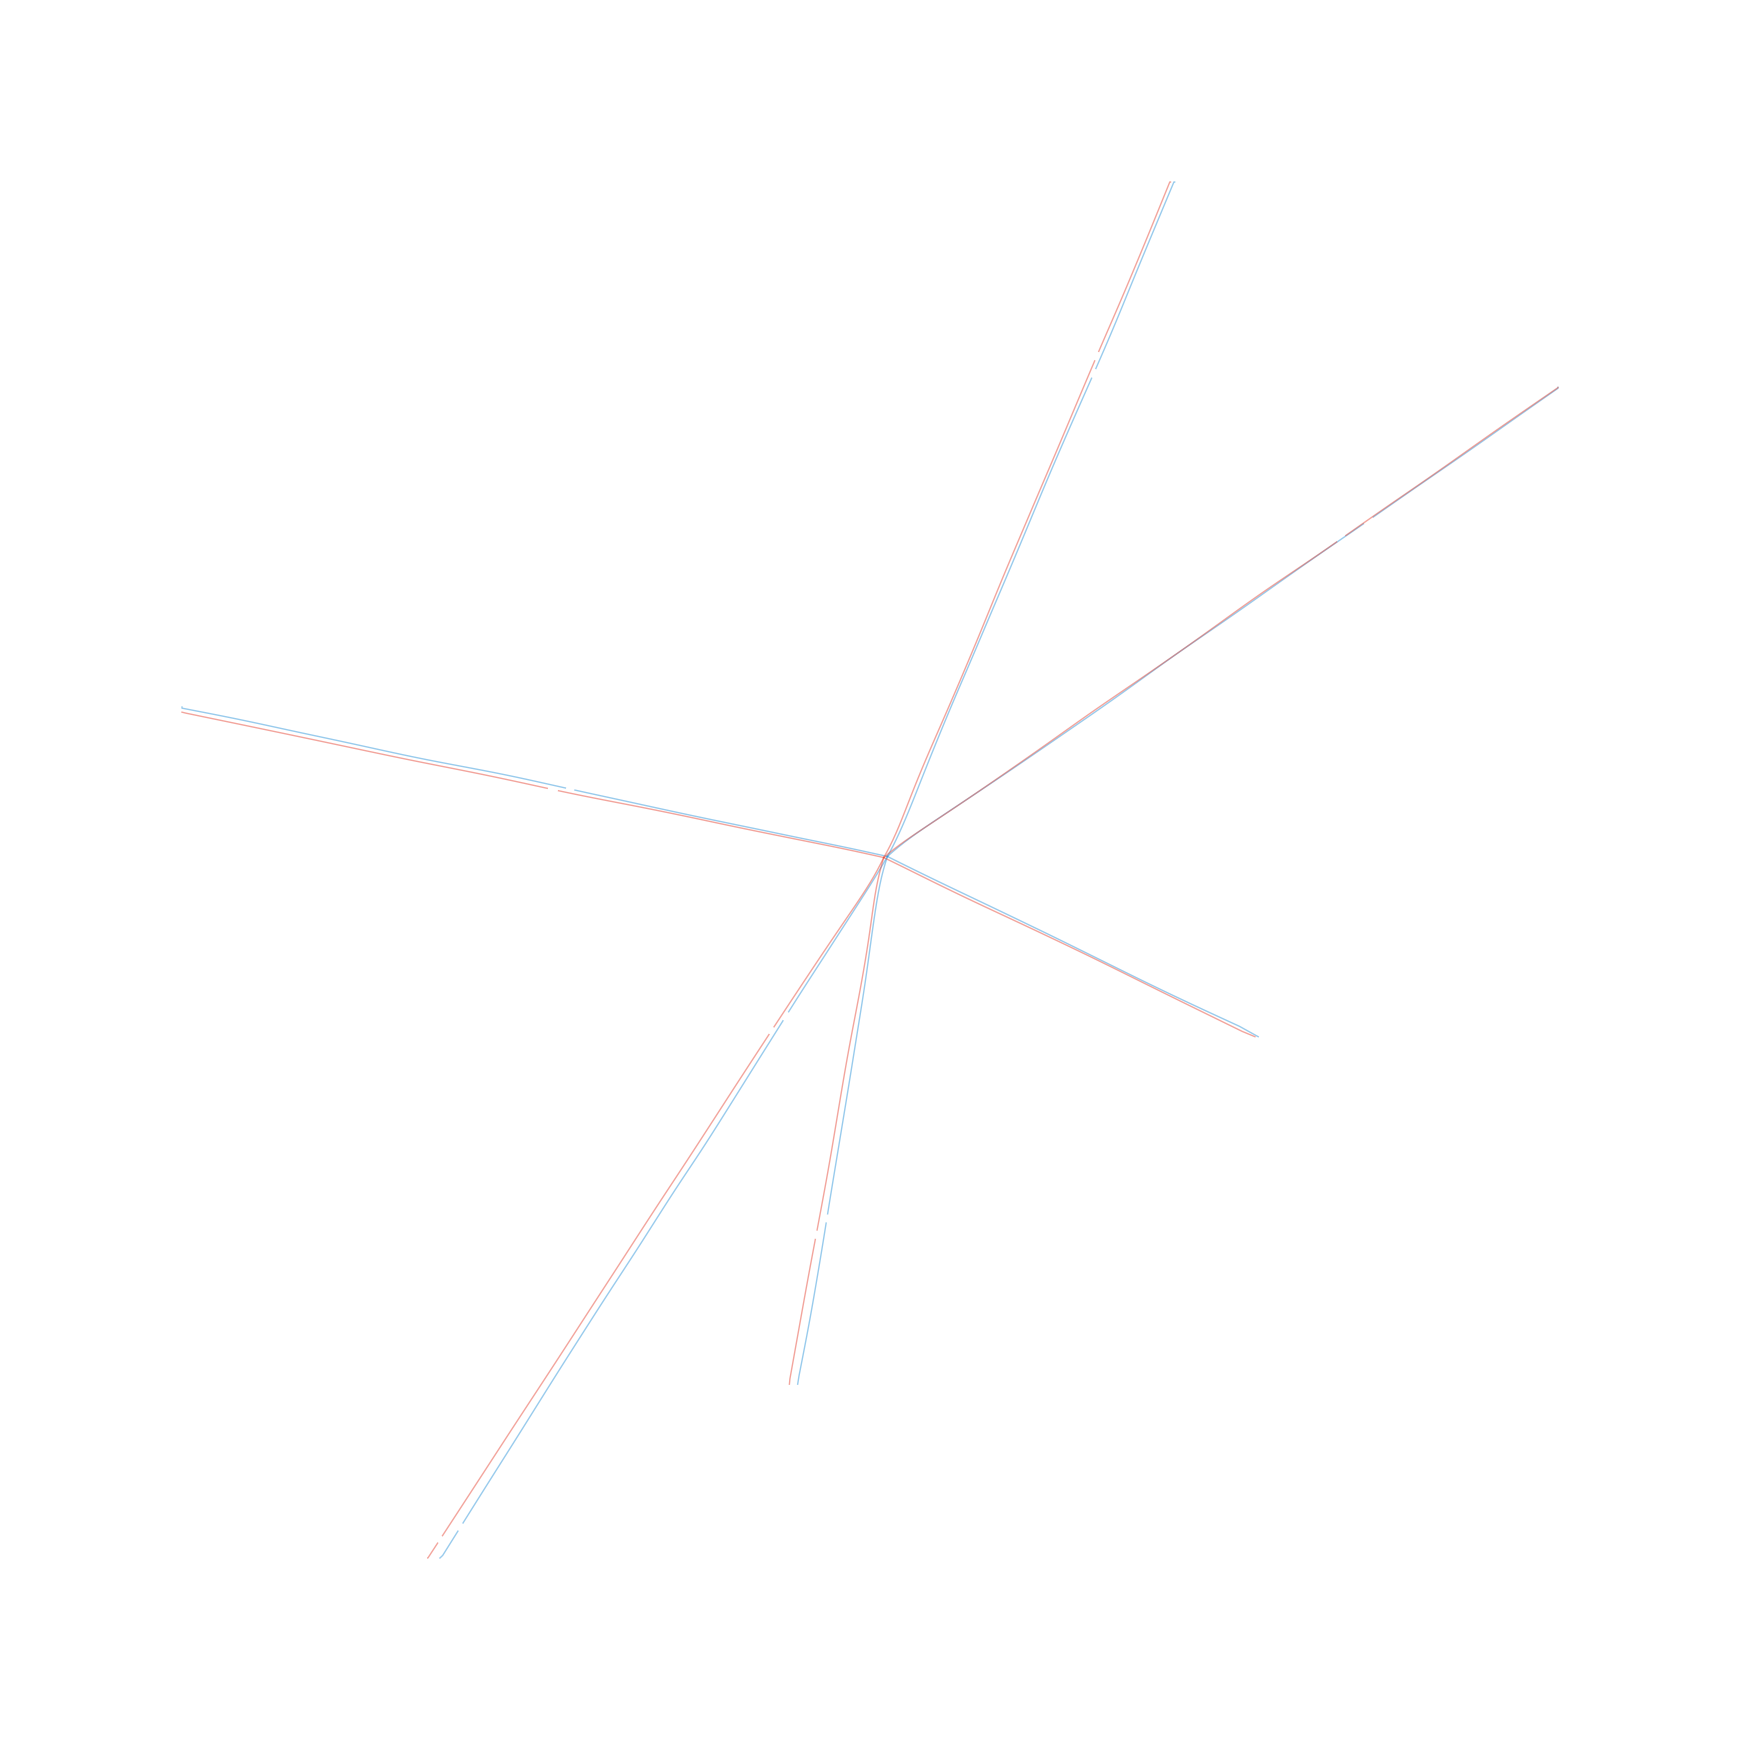

In [77]:
plot_blood_vessels_with_bundling(
    G_lung_heart_arteries, 
    G_lung_heart_veins, 
    vein_pos_lung_heart, 
    artery_pos_lung_heart, 
    'lung_heart'
)